# Credit Scoring Model
### CodeAlpha Machine Learning Internship - Task 1

The goal is to predict whether a person will default on a loan
based on their financial history.

Dataset: Give Me Some Credit (Kaggle)
Models used: Logistic Regression, Decision Tree, Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

print("libraries imported")

libraries imported


In [2]:
df = pd.read_csv('data/cs-training.csv')

# the dataset has an unnamed index column, remove it
df.drop(columns=['Unnamed: 0'], inplace=True)

print("shape:", df.shape)
df.head()

shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


---
## 1. Exploratory Data Analysis

Before building any model, I want to understand the data —
what columns exist, are there missing values, what does the target look like.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [4]:
# the original column names are too long, renaming them for readability
df.rename(columns={
    'SeriousDlqin2yrs'                         : 'default',
    'RevolvingUtilizationOfUnsecuredLines'      : 'revolving_util',
    'age'                                       : 'age',
    'NumberOfTime30-59DaysPastDueNotWorse'      : 'late_30_59',
    'DebtRatio'                                 : 'debt_ratio',
    'MonthlyIncome'                             : 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans'           : 'open_credit_lines',
    'NumberOfTimes90DaysLate'                   : 'late_90',
    'NumberRealEstateLoansOrLines'              : 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse'      : 'late_60_89',
    'NumberOfDependents'                        : 'dependents'
}, inplace=True)

print(df.columns.tolist())

['default', 'revolving_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'late_90', 'real_estate_loans', 'late_60_89', 'dependents']


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
default                  0
revolving_util           0
age                      0
late_30_59               0
debt_ratio               0
monthly_income       29731
open_credit_lines        0
late_90                  0
real_estate_loans        0
late_60_89               0
dependents            3924
dtype: int64


In [6]:
print("Default value counts:")
print(df['default'].value_counts())

print("\nDefault rate:", round(df['default'].mean() * 100, 2), "%")

Default value counts:
default
0    139974
1     10026
Name: count, dtype: int64

Default rate: 6.68 %


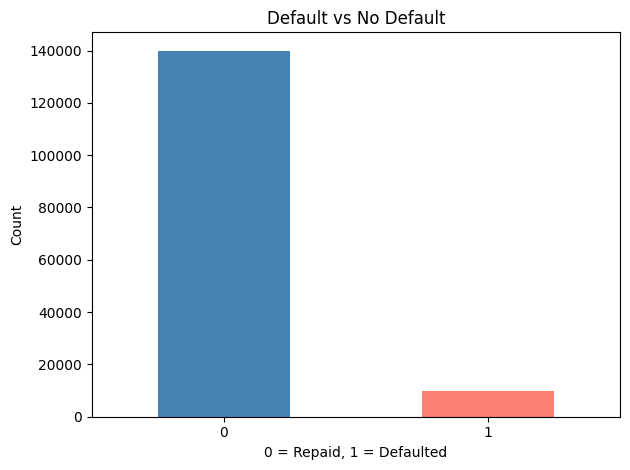

In [7]:
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Default vs No Default')
plt.xlabel('0 = Repaid, 1 = Defaulted')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png')
plt.show()

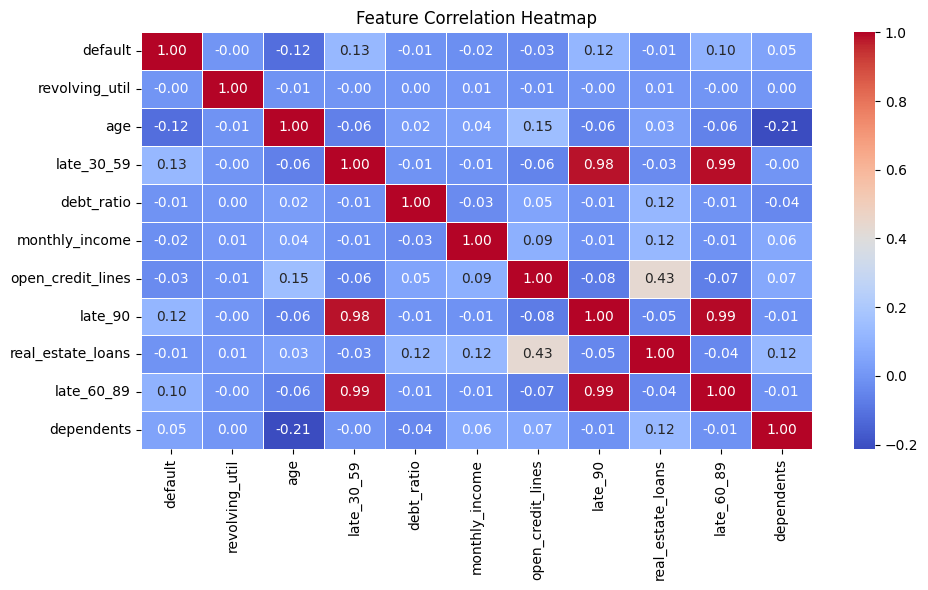

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('reports/figures/correlation_heatmap.png')
plt.show()

---
## 2. Data Preprocessing

Cleaning the data — handling missing values, fixing bad data,
and preparing it for the models.

In [9]:
# monthly_income - filling with median
# median is better than mean here because income data is skewed
df['monthly_income'].fillna(df['monthly_income'].median(), inplace=True)

# dependents just has a few missing - filling with mode.
df['dependents'].fillna(df['dependents'].mode()[0], inplace=True)

# fix age = 0 which is not possible for a loan applicant
df['age'] = df['age'].replace(0, df['age'].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
default              0
revolving_util       0
age                  0
late_30_59           0
debt_ratio           0
monthly_income       0
open_credit_lines    0
late_90              0
real_estate_loans    0
late_60_89           0
dependents           0
dtype: int64


In [10]:
# some columns have extreme outlier values that don't make sense
# we cap them at the 99th percentile to reduce their effect on the model
cols = ['revolving_util', 'debt_ratio', 'monthly_income']

for col in cols:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

print("Outliers capped at 99th percentile for:", cols)
print(df[cols].describe())

Outliers capped at 99th percentile for: ['revolving_util', 'debt_ratio', 'monthly_income']
       revolving_util     debt_ratio  monthly_income
count   150000.000000  150000.000000   150000.000000
mean         0.320496     316.548869     6142.445313
std          0.352152     906.962222     3835.678657
min          0.000000       0.000000        0.000000
25%          0.029867       0.175074     3903.000000
50%          0.154181       0.366508     5400.000000
75%          0.559046       0.868254     7400.000000
max          1.092956    4979.040000    23000.000000


In [ ]:
# creating a new feature that combines all late payment columns
# a person who was late many times across all categories is a higher risk
df['total_late_payments'] = df['late_30_59'] + df['late_60_89'] + df['late_90']

print("New feature added: total_late_payments")
print(df['total_late_payments'].describe())